In [1]:
import numpy as np
from scipy.constants import h, c, k
from scipy.integrate import quad
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import os
import datetime
import csv
from datetime import datetime

In [9]:
# === SETTINGS ===
ID = "A2"  # Station ID

# === File Paths ===
dir_path = Path.cwd()  # current working directory
print("Current working directory:", dir_path)

# Data directory 
data_dir = dir_path.parent / "data"
# Protocols directory 
protocol_dir = dir_path.parent / "protocols"
# Halobates data directory 
halobates_dir =  data_dir / "halobates_data"
# Results directory 
results_dir = dir_path.parent / "results"
# Raw SST temperature directory
out_dir = dir_path / "raw"
# Averaged SST temperature directory
out_dir_avg = dir_path / "1min"



# Halobates file
halobates_file = sorted(halobates_dir.glob(f"{ID}_Halobates.csv"))
halobates_file  = str(halobates_file[0])

# Halobates protocol file
protocol_file = sorted(protocol_dir.glob(f"*{ID}_17_CST_Schedule.csv"))
protocol_file  = str(protocol_file[0])

# SST temperature file 
sst_file = sorted(out_dir.glob(f"*{ID}_17_IR_SST.csv"))
sst_file  = str(sst_file[0])

# Output path for SST vs SML data
sst_sml_output_file = results_dir / "SST_vs_SML.csv"

# === Debug output (optional) ===
print("Halobates data file:", halobates_file)
print("Halobates protocol file:", protocol_file)

Current working directory: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\postproc
Halobates data file: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\data\halobates_data\A2_Halobates.csv
Halobates protocol file: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\protocols\20250629_A2_17_CST_Schedule.csv


### Clip SST temperatures based on Halobates protocol

C:\Users\ludog\AppData\Local\Temp\ipykernel_14096\3148983502.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])


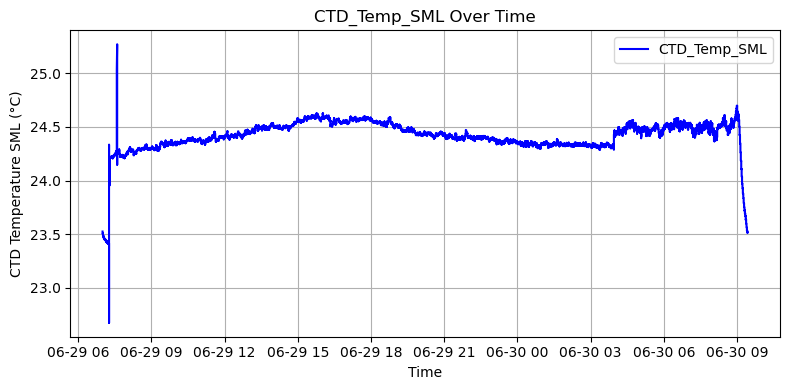

In [78]:
# Load Halobates data
df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])

# Rename time column for consistency    
df_halo  = df_halo.rename(columns={'Date_Time': 'Time'})

# Plot SML temperature 
plt.figure(figsize=(8, 4))
plt.plot(df_halo['Time'], df_halo['CTD_Temp_SML'], label='CTD_Temp_SML', color='blue')
plt.xlabel('Time')
plt.ylabel('CTD Temperature SML (°C)')
plt.title('CTD_Temp_SML Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
# === Load Halobates protocol data ===
df_protocol = pd.read_csv(protocol_file, sep=";", decimal=",")

# Convert 'Date_Time' column to datetime format
for col in df_protocol.columns[1:]:
    df_protocol[col] = pd.to_datetime(df_protocol[col], format="%d.%m.%Y %H:%M:%S", errors='coerce').dt.strftime("%Y-%m-%d %H:%M:%S")

df_protocol


,Event,Start,End
0,Deployment/Recover time,2025-06-29 07:14:00,2025-06-30 09:10:00
1,Bridge up/down,2025-06-29 07:14:00,2025-06-30 08:54:00
2,Intervention,2025-06-29 07:14:00,2025-06-29 09:15:00
3,Intervention,2025-06-29 13:09:00,2025-06-29 13:15:00
4,Intervention,2025-06-29 14:13:00,2025-06-29 14:15:00
5,Intervention,2025-06-29 14:32:00,2025-06-29 14:36:00
6,Intervention,2025-06-29 18:38:00,2025-06-29 18:48:00
7,Intervention,2025-06-30 08:42:00,2025-06-30 08:54:00


In [80]:
# Load SST data
df_sst = pd.read_csv(sst_file, parse_dates=['Time'])

df_sst.head()


,Time,SST (°C)
0,2025-06-29 06:44:14,22.525578
1,2025-06-29 06:44:15,22.533884
2,2025-06-29 06:44:16,22.539678
3,2025-06-29 06:44:17,22.571941
4,2025-06-29 06:44:18,22.530287


In [81]:
# Function to compute anomaly threshold based on mean and standard deviation of the data before the intervention
def compute_threshold(ts: pd.Series, start: pd.Timestamp, end: pd.Timestamp, num_std: float = 2) -> float:
    """
    Compute anomaly threshold = mean + num_std * std of ts between start and end.
    """
    ref = ts[start:end]
    return ref.mean() + num_std * ref.std()

# Remove intervention windows from SST data if data is above the threshold
def clean_sst(
    df_sst: pd.DataFrame,
    df_protocol: pd.DataFrame,
    sst_variable: str,
    shift_s: int = 300
) -> pd.DataFrame:
    """
    Clean SST data by:
      1) Clipping to deployment and bridge intervals.
      2) Masking all SST values within each protocol interval,
         extending the mask start backward if early peaks above threshold occur.

    Parameters:
        df_sst       - DataFrame with ['Time', sst_variable].
        df_protocol  - Protocol DF with ['Start', 'End']:
                           row 0: deployment,
                           row 1: bridge,
                           rows 2+: intervention windows.
        sst_variable - Name of the SST column.
        shift_s      - Seconds before scheduled start to compute baseline and lookback.

    Returns:
        DataFrame with cleaned SST and 'Time' column.
    """
    # Prepare SST series
    df = df_sst.copy()
    df['Time'] = pd.to_datetime(df['Time'])
    df = df.set_index('Time').sort_index()
    ts = df[sst_variable].copy()

    # Clip to deployment window (row 0) -> not necessary since bridge up and down later 
    #dep_start = pd.to_datetime(df_protocol.loc[0, 'Start'])
    #dep_end   = pd.to_datetime(df_protocol.loc[0, 'End'])
    #cleaned = ts[dep_start:dep_end].copy()

    # Clip to bridge window within deployment (row 1)
    bridge_start = pd.to_datetime(df_protocol.loc[1, 'Start'])
    bridge_end   = pd.to_datetime(df_protocol.loc[1, 'End'])
    cleaned = ts[bridge_start:bridge_end].copy()

    # For each intervention window (rows 2+), mask full interval,
    # but extend start backward to first pre-start spike above threshold.
    for _, row in df_protocol.iloc[2:].iterrows():
        sched_start = pd.to_datetime(row['Start'])
        sched_end   = pd.to_datetime(row['End'])

        # Baseline window for threshold: [sched_start - shift_s, sched_start]
        baseline_start = sched_start - pd.Timedelta(seconds=shift_s)
        threshold = compute_threshold(cleaned, baseline_start, sched_start)

        # Look back same shift_s seconds for early spikes
        pre_start = baseline_start
        pre_window = cleaned[pre_start:sched_start]
        spikes = pre_window[pre_window > threshold]
        # If any spikes, start mask at earliest spike; else at scheduled start
        actual_start = spikes.index.min() if not spikes.empty else sched_start

        # Mask the entire scheduled interval, starting from actual_start
        cleaned.loc[actual_start:sched_end] = np.nan

    # Return cleaned series as DataFrame
    return cleaned.reset_index()

In [82]:
sst_cleaned = clean_sst(df_sst, df_protocol, sst_variable="SST (°C)", shift_s=300) #Shift is the number of seconds before the scheduled start to define the "clean" reference window

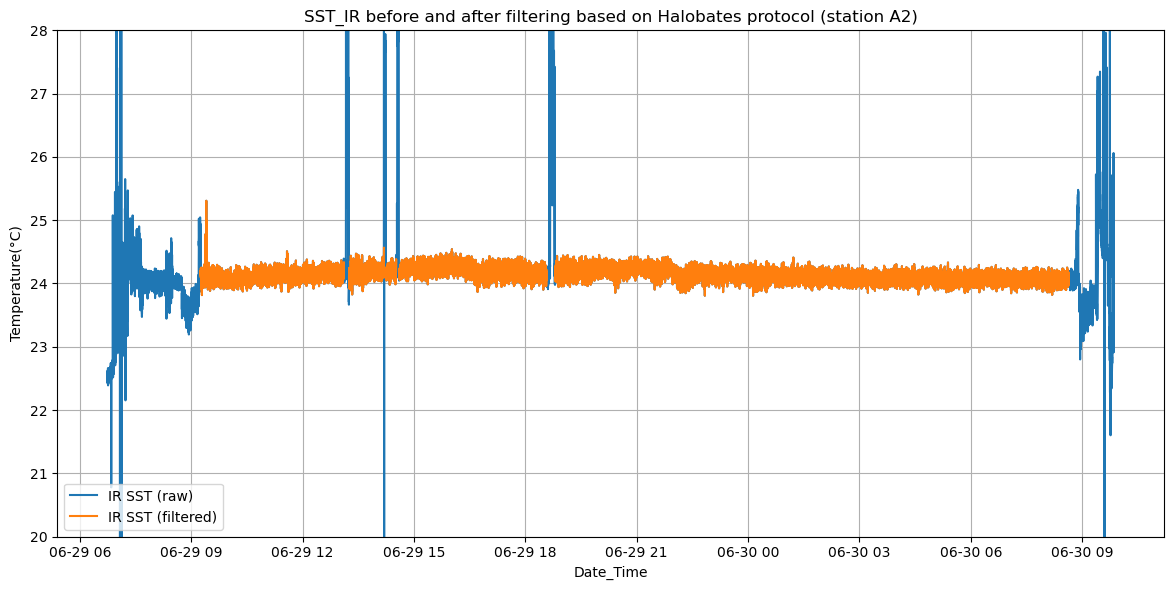

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(df_sst['Time'], df_sst["SST (°C)"], label='IR SST (raw)')
plt.plot(sst_cleaned['Time'], sst_cleaned["SST (°C)"], label='IR SST (filtered)')
plt.xlabel('Date_Time')
plt.ylabel('Temperature(°C)')
plt.title(f'SST_IR before and after filtering based on Halobates protocol (station {ID})')
plt.legend(loc = "lower left")
plt.grid(True)
plt.tight_layout()

plt.ylim(20, 28)

plt.show()

#### Remove futher peaks (?)

In [92]:
# Remove further peaks using additional filters

# Mask values outside [min_val, max_val] by setting them to NaN.
def clip_data(series: pd.Series, min_val: float, max_val: float) -> pd.Series:
    """
    Mask values outside [min_val, max_val] by setting them to NaN.
    """
    return series.where(series.between(min_val, max_val))

# Compute a symmetric Exponentially Weighted Moving Average (EWMA) by forward and backward passes.
def ewma_forward_backward(series: pd.Series, span: int) -> pd.Series:
    """
    Compute a symmetric EWMA by forward and backward passes.
    """
    fwd = series.ewm(span=span, adjust=False).mean()
    bwd = series[::-1].ewm(span=span, adjust=False).mean()[::-1]
    return (fwd + bwd) / 2

# Remove points that deviate from reference by more than delta.
def remove_delta_outliers(series: pd.Series, reference: pd.Series, delta: float) -> pd.Series:
    """
    Mask points that deviate from reference by more than delta.
    """
    return series.mask((series - reference).abs() > delta)

# Remove values beyond num_std standard deviations from the mean.
def remove_std_outliers(series: pd.Series, num_std: float = 2) -> pd.Series:
    """
    Mask values beyond num_std standard deviations from the mean.
    """
    m, s = series.mean(), series.std()
    return series.mask((series - m).abs() > num_std * s)

In [101]:
# === Apply all functions to remove peaks
min_sst = 22  # Define a minimum SST value to clip
max_sst = 26  # Define a maximum SST value to clip

sst_removepeaks = sst_cleaned.copy()
sst_removepeaks['y_clipped']       = clip_data(sst_removepeaks['SST (\u00b0C)'], min_sst, max_sst)
sst_removepeaks['y_ewma_fb']       = ewma_forward_backward(sst_removepeaks['y_clipped'], span=100)
sst_removepeaks['y_no_delta']      = remove_delta_outliers(sst_removepeaks['y_clipped'], sst_removepeaks['y_ewma_fb'], delta=0.45)
sst_removepeaks['y_no_peaks']      = remove_std_outliers(sst_removepeaks['y_no_delta'], num_std=2)

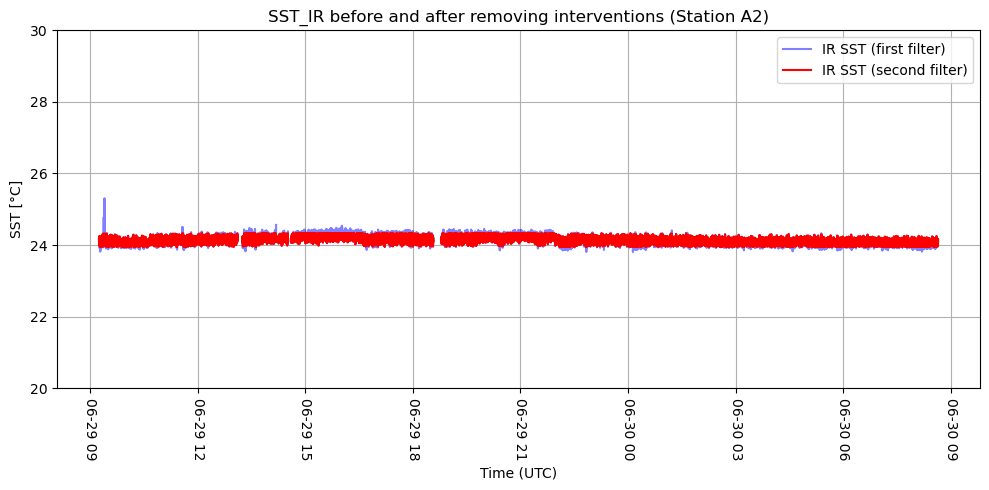

In [102]:
# PLOT
plt.figure(figsize=(10, 5))
plt.plot(sst_removepeaks["Time"], sst_removepeaks["SST (°C)"], alpha=0.5, label='IR SST (first filter)', color='blue')
plt.plot(sst_removepeaks["Time"], sst_removepeaks['y_no_peaks'], label='IR SST (second filter)', color='red')


plt.xlabel("Time (UTC)")
plt.ylabel("SST [°C]")
plt.title(f"SST_IR before and after removing interventions (Station {ID})")
plt.xticks(rotation=-90)

plt.ylim(20, 30)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Compare with Halobates SML temperature

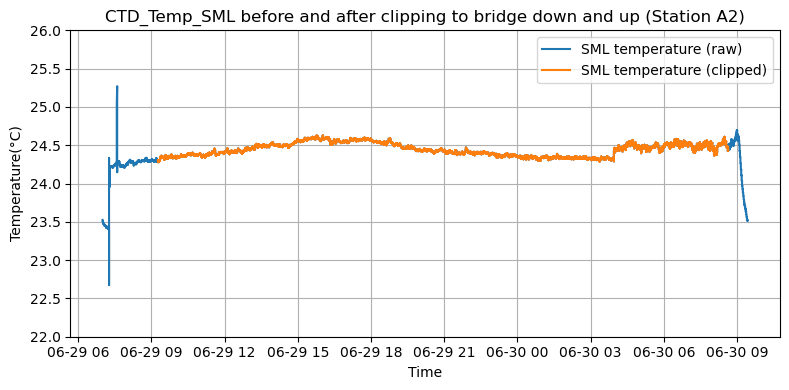

In [110]:
# Apply same filtering based on Halobates protocol to Habolates SML temperature
#halo_sml_temp = clean_sst(df_halo, df_protocol, sst_variable="CTD_Temp_SML", shift_s=300)

df_halo['Time'] = pd.to_datetime(df_halo['Time'])
df_temp = df_halo.set_index('Time').sort_index()

#Clip Halobates data to IR camera data
non_na = sst_cleaned.dropna(subset=['SST (°C)'])
start_time = non_na['Time'].min()
end_time   = non_na['Time'].max()


mask = (df_halo['Time'] >= start_time) & (df_halo['Time'] <= end_time)
df_halo_clipped = df_halo.loc[mask].copy()

plt.figure(figsize=(8, 4))
plt.plot(df_halo['Time'], df_halo["CTD_Temp_SML"], label='SML temperature (raw)')
plt.plot(df_halo_clipped['Time'], df_halo_clipped['CTD_Temp_SML'], label='SML temperature (clipped)')
plt.xlabel('Time')
plt.ylabel('Temperature(°C)')
plt.title(f'CTD_Temp_SML before and after clipping to bridge down and up (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(22, 26)
plt.show()

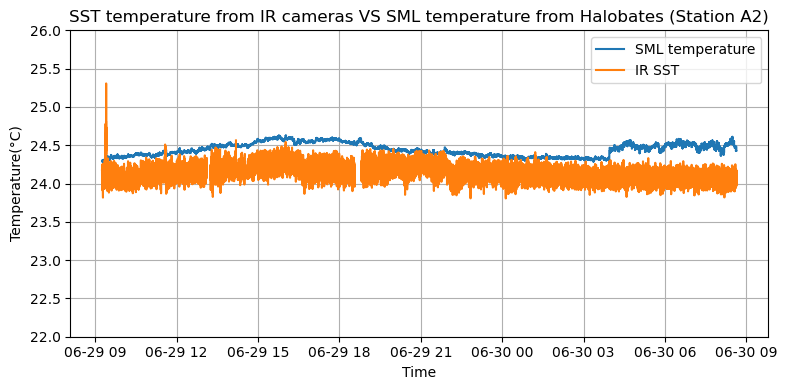

In [111]:
# Compare Halobates SML temperature with SST after removing peaks

plt.figure(figsize=(8, 4))
plt.plot(df_halo_clipped['Time'], df_halo_clipped['CTD_Temp_SML'], label='SML temperature')
plt.plot(sst_cleaned['Time'], sst_cleaned["SST (°C)"], label='IR SST')
plt.xlabel('Time')
plt.ylabel('Temperature(°C)')
plt.title(f'SST temperature from IR cameras VS SML temperature from Halobates (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(22, 26)
plt.show()


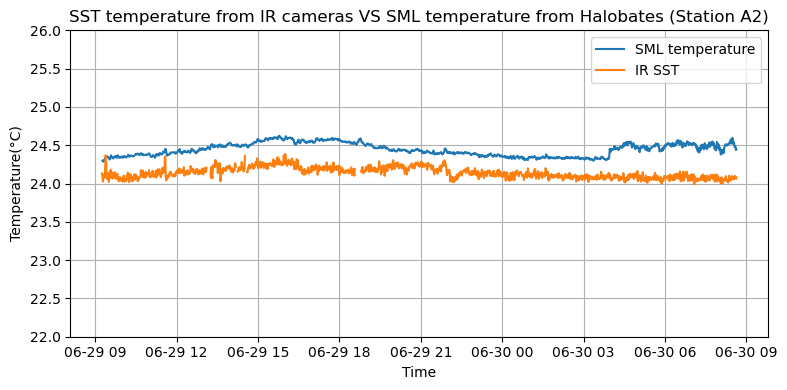

In [112]:
# Calculate 1 minute averages
sst_cleaned_avg = sst_cleaned.set_index('Time').resample('1min').mean().reset_index()
df_halo_avg = df_halo_clipped.set_index('Time').resample('1min').mean().reset_index()


plt.figure(figsize=(8, 4))
plt.plot(df_halo_avg['Time'], df_halo_avg['CTD_Temp_SML'], label='SML temperature')
plt.plot(sst_cleaned_avg['Time'], sst_cleaned_avg["SST (°C)"], label='IR SST')
plt.xlabel('Time')
plt.ylabel('Temperature(°C)')
plt.title(f'SST temperature from IR cameras VS SML temperature from Halobates (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(22, 26)
plt.show()
